In [42]:
import pandas as pd

dataset = pd.read_csv("../data/dataset/primaria_dataset.csv")
dataset.columns
dataset.head()

,gestion,anio_escolaridad,paralelo,nro.,paterno,materno,nombres,rude,gen,fecha_nac,...,edu_musical,art_plasticas,matematica,tec_tecnologica,cs_naturales,valores_religion,archivo_origen,rezago,num_materias_reprobadas,promedio_general
0,2022,PRIMERO,B,1,NaN,FERNANDEZ,AYELEN BELEN,809800682020086,F,09-07-2015,...,84.0,87.0,89.0,90.0,90.0,91.0,boletin_centralizador_80980027_12_Primero_B_20...,0,0,88.333333
1,2022,PRIMERO,B,2,NaN,HINOJOSA,ARELI LUCIA,609000282018010,F,31-10-2013,...,NaN,NaN,NaN,NaN,NaN,NaN,boletin_centralizador_80980027_12_Primero_B_20...,0,0,NaN
2,2022,PRIMERO,B,3,ALANES,FUENTES,DESIRE CIELO,809804752020027,F,11-08-2015,...,79.0,69.0,67.0,69.0,66.0,92.0,boletin_centralizador_80980027_12_Primero_B_20...,0,0,73.777778
3,2022,PRIMERO,B,4,ALVAREZ,SEJAS,REYCHEL,809801842020002,F,10-09-2015,...,73.0,54.0,55.0,54.0,52.0,65.0,boletin_centralizador_80980027_12_Primero_B_20...,0,0,59.333333
4,2022,PRIMERO,B,5,APAZA,CARVAJAL,KAROLAY FELISA,809801202020120,F,28-04-2016,...,56.0,52.0,51.0,51.0,51.0,41.0,boletin_centralizador_80980027_12_Primero_B_20...,1,2,51.444444


In [43]:
# Ordenar por rude and gestion

dataset = dataset.sort_values(["rude", "gestion"])
dataset.reset_index(drop=True, inplace=True)

In [44]:
# Crear variables del año anterior

features_base = [
    "promedio_general",
    "num_materias_reprobadas"
]

for col in features_base:
    dataset[f"{col}_prev"] = dataset.groupby("rude")[col].shift(1)


In [45]:
# Objetivo futuro

dataset["rezago_next"] = dataset.groupby("rude")["rezago"].shift(-1)


In [46]:
# Dataset de modelado

model_data = dataset.dropna(subset=[
    "promedio_general_prev",
    "num_materias_reprobadas_prev",
    "rezago_next"
])


In [47]:
# Aniadir curso y paralelo

model_data = pd.get_dummies(
    model_data,
    columns=["anio_escolaridad", "paralelo"],
    drop_first=True
)


In [48]:
# Definir X e y

features = [
    "promedio_general_prev",
    "num_materias_reprobadas_prev"
]

X = model_data[features]
y = model_data["rezago_next"]


In [49]:
# Separación Train / Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [50]:
# Arbol de decision

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [51]:
# Randon Forest 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [52]:
# Evaluacion 

from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[49  1]
 [ 1  0]]
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98        50
         1.0       0.00      0.00      0.00         1

    accuracy                           0.96        51
   macro avg       0.49      0.49      0.49        51
weighted avg       0.96      0.96      0.96        51



<Axes: title={'center': 'Proporción de rezago por gestión'}, xlabel='gestion'>

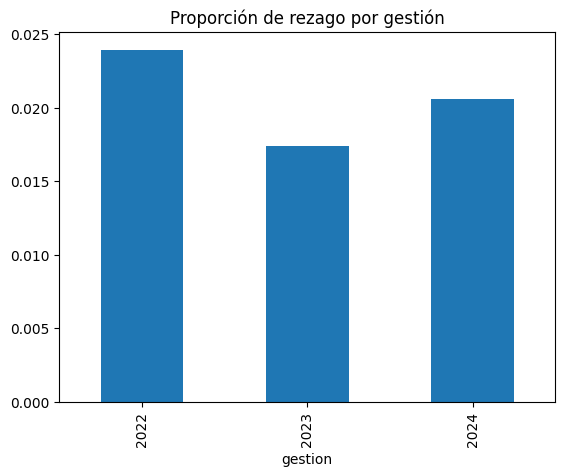

In [53]:
# Evolución de rezago por año

dataset.groupby("gestion")["rezago"].mean().plot(
    kind="bar",
    title="Proporción de rezago por gestión"
)

<Axes: title={'center': 'Rezago promedio por curso'}, xlabel='anio_escolaridad'>

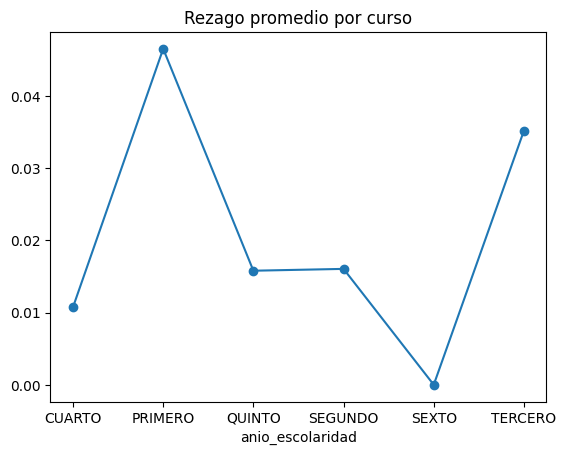

In [54]:
# Rezago por curso

dataset.groupby("anio_escolaridad")["rezago"].mean().sort_index().plot(
    kind="line",
    marker="o",
    title="Rezago promedio por curso"
)

In [55]:
# Comparación paralelo A vs B

dataset.groupby("paralelo")["rezago"].mean()


paralelo
A    0.016071
B    0.025090
Name: rezago, dtype: float64

<Axes: title={'center': 'Evolución académica de un estudiante'}, xlabel='gestion'>

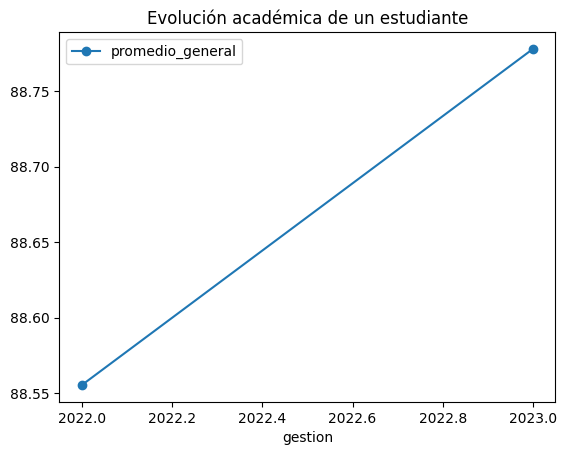

In [56]:
# Trayectorias individuales (opcional pero top)

ejemplo = dataset[dataset["rude"] == dataset["rude"].iloc[0]]

ejemplo.plot(
    x="gestion",
    y="promedio_general",
    marker="o",
    title="Evolución académica de un estudiante"
)


In [59]:
# Ajuste

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)   # ← ESTE PASO ES CLAVE


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [60]:
model_data = X_test.copy()

model_data["prob_rezago"] = rf.predict_proba(X_test)[:, 1]
model_data["rezago_real"] = y_test.values

In [61]:
def nivel_riesgo(p):
    if p >= 0.7:
        return "Alto"
    elif p >= 0.4:
        return "Medio"
    else:
        return "Bajo"

model_data["nivel_riesgo"] = model_data["prob_rezago"].apply(nivel_riesgo)


In [62]:
model_data["nivel_riesgo"].value_counts()


nivel_riesgo
Bajo     50
Medio     1
Name: count, dtype: int64

In [63]:
model_data


,promedio_general_prev,num_materias_reprobadas_prev,prob_rezago,rezago_real,nivel_riesgo
1079,78.666667,0.0,0.000,0.0,Bajo
347,74.888889,0.0,0.000,0.0,Bajo
446,84.666667,0.0,0.000,0.0,Bajo
846,84.777778,0.0,0.000,0.0,Bajo
715,56.111111,0.0,0.000,0.0,Bajo
1041,89.777778,0.0,0.000,0.0,Bajo
151,57.111111,0.0,0.000,0.0,Bajo
636,63.777778,0.0,0.000,0.0,Bajo
793,84.000000,0.0,0.000,0.0,Bajo
993,57.555556,0.0,0.000,0.0,Bajo
